Task-01

"Create a bar chart or histogram to visualize the distribution of a categorical or continuous variable, such as the distribution of ages or genders in a population."

Sample Dataset :-
https://data.worldbank.org/indicator/SP.POP.TOTL

.TOTL



# Problem Statement:-

Governments, NGOs, and global organizations require accurate and visual representations of population data to make informed decisions on resource allocation, healthcare, infrastructure, and economic planning. The raw population figures available through the World Bank dataset are extensive but require proper analysis and visualization to draw meaningful insights.

This task focuses on extracting and visualizing the population data of countries to better understand global population distribution and identify countries with the highest population growth or size.

# Business Objectives:-

1)Analyze and visualize the total population of countries using the World Bank dataset.

2)Identify top populated countries in a recent year (e.g., 2022).

3)Understand population distribution across countries using histograms.

4)Present insights through clear and informative visualizations to support data-driven decision-making.



In [177]:
#import necessary libraries
import pandas as pd #for load dataset
import matplotlib.pyplot as plt #to visualize the data
import pycountry #to get only country

In [178]:
#load the csv dataset file
data = pd.read_csv("API_SP.POP.TOTL_DS2_en_csv_v2_19373.csv", skiprows=4)
#skiprows for data header contain first 4 empty row so remove it

In [179]:
#check size of data
data.shape

(266, 70)

In [180]:
#there are 266 rows and 70 columns

In [181]:
#check which columns are present in dataset
data.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', 'Unnamed: 69'],
      dtype='object')

In [182]:
#rename the column name

In [183]:
data = data.rename(columns={'Country Name':"country_name",'Country Code':'country_code','Indicator Name':'indicator_name','Indicator Code':'indicator_code'})

In [184]:
#check header of data
data.head()

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130072080.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750503764.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,NaN,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106388440.0,108772632.0,...,429454743.0,440882906.0,452195915.0,463365429.0,474569351.0,485920997.0,497387180.0,509398589.0,NaN,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,NaN,NaN


In [185]:
data.tail()

,country_name,country_code,indicator_name,indicator_code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,Unnamed: 69
261,Kosovo,XKX,"Population, total",SP.POP.TOTL,984846.0,1011421.0,1036950.0,1062737.0,1090270.0,1120168.0,...,1777568.0,1791019.0,1797086.0,1788891.0,1790152.0,1786080.0,1768096.0,1756366.0,NaN,NaN
262,"Yemen, Rep.",YEM,"Population, total",SP.POP.TOTL,5532301.0,5655232.0,5782221.0,5911135.0,6048006.0,6195593.0,...,32109010.0,33090921.0,34085182.0,35111408.0,36134863.0,37140230.0,38222876.0,39390799.0,NaN,NaN
263,South Africa,ZAF,"Population, total",SP.POP.TOTL,16440172.0,16908035.0,17418522.0,17954564.0,18511361.0,19089380.0,...,57259551.0,57635162.0,58613001.0,59587885.0,60562381.0,61502603.0,62378410.0,63212384.0,NaN,NaN
264,Zambia,ZMB,"Population, total",SP.POP.TOTL,3153729.0,3254086.0,3358099.0,3465907.0,3577017.0,3692086.0,...,16914423.0,17441320.0,17973569.0,18513839.0,19059395.0,19603607.0,20152938.0,20723965.0,NaN,NaN
265,Zimbabwe,ZWE,"Population, total",SP.POP.TOTL,3809389.0,3930401.0,4055959.0,4185877.0,4320006.0,4458462.0,...,14600294.0,14812482.0,15034452.0,15271368.0,15526888.0,15797210.0,16069056.0,16340822.0,NaN,NaN


In [186]:
#from above we can unterstand that this data is about population of all country from year 1960 to 2024

In [187]:
#remove unnecessary columns 'Country Code','Indicator Name', 'Indicator Code', 'Unnamed: 69'
data = data.drop(['Unnamed: 69'],axis=1)

In [188]:
data.columns

Index(['country_name', 'country_code', 'indicator_name', 'indicator_code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='object')

In [189]:
#unnecessary columns are drop

In [190]:
#check missing values
missing_values = data.isnull().sum()

In [191]:
print(missing_values)

country_name        0
country_code        0
indicator_name      0
indicator_code      0
1960                2
                 ... 
2020                1
2021                1
2022                1
2023                1
2024              266
Length: 69, dtype: int64


In [192]:
#remove missing values by mean imputation method
# it should apply only of numerical columns

In [193]:
#convert year columns to numeric values and , coercing errors into NaN
year_columns = data.columns[4:] #exclude first 4 columns are non-numeric
data[year_columns] = data[year_columns].apply(pd.to_numeric, errors='coerce') 


In [194]:
#fill NaN value with mean of column i.e do mean imputation
data[year_columns] = data[year_columns].fillna(data[year_columns].mean())

In [195]:
data.isnull().sum()

country_name        0
country_code        0
indicator_name      0
indicator_code      0
1960                0
                 ... 
2020                0
2021                0
2022                0
2023                0
2024              266
Length: 69, dtype: int64

In [196]:
#after doing mean imputation still in 2024 year column 266 missing value
#it means 2024 year column are empty 
#so we can drop it

In [197]:
data = data.drop(['2024'],axis=1)

In [198]:
data.columns

Index(['country_name', 'country_code', 'indicator_name', 'indicator_code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')

# Bar Chart

In [199]:
# bar chart is for categorical data
#Bar chart helps in comparing individual country populations.
#in datset country name is categorical so we plot bar chart for it

In [200]:
#we visualize the top 30 most populous countries in 2023 from the dataset. 
#Each bar represents the total population (in billions) for a country.

In [201]:
#get only country name from datset by using pycountry module
only_country = {country.name for country in pycountry.countries}

# Filter only rows where the country name exists in this list
valid_countries = data[data['country_name'].isin(only_country)]

# top 15 countries of population

In [202]:
# Get the top 15 countries by population in 2023
top15 = valid_countries[['country_name', '2023']].dropna().sort_values('2023', ascending=False).head(15)

print(top15)

           country_name          2023
109               India  1.438070e+09
40                China  1.410710e+09
251       United States  3.349149e+08
106           Indonesia  2.811901e+08
184            Pakistan  2.475045e+08
174             Nigeria  2.278829e+08
29               Brazil  2.111407e+08
20           Bangladesh  1.714670e+08
202  Russian Federation  1.438261e+08
154              Mexico  1.297398e+08
72             Ethiopia  1.286917e+08
119               Japan  1.245166e+08
187         Philippines  1.148912e+08
257            Viet Nam  1.003522e+08
55              Germany  8.328000e+07


# bar chart for top 15 countries in 2023

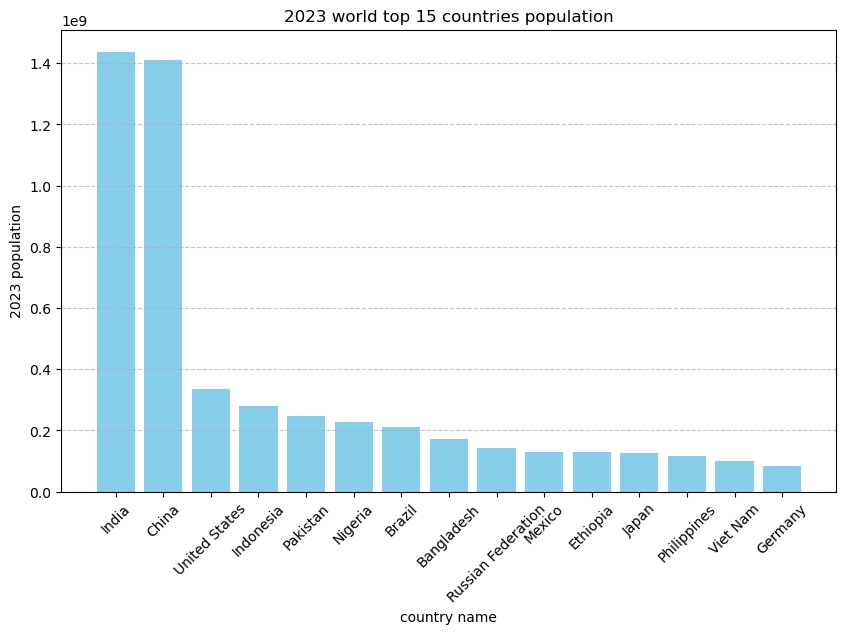

In [203]:
plt.figure(figsize=(10,6))
plt.bar(top15['country_name'],top15['2023'],color="skyblue")
plt.title("2023 world top 15 countries population")
plt.xlabel("country name")
plt.ylabel("2023 population")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [204]:
#from above graph we can observe that India has highest population
#from above graph we can observe that India and China has most population their is large difference between this two countries and all other countries
#india and china has above 1.4 billion population in 2023 
#united states, indonesia, pakistan, nigeria, brazil this countries have population in between 0.4 to 0.2 billion
#so we can see the difference between india - china and other countries i.e it is upto 1.3 million difference
# Bangladesh, Russian Federation, Mexico, Ethiopia, Japan, Philippines, Viet Nam, Germany  this countries has population has same range i.e 0.1 

# Lowest population bottom 15 countries in 2023

In [212]:
# Get the bottom 15 countries by population in 2023
bottom15 = valid_countries[['country_name', '2023']].dropna().sort_values('2023', ascending=True).head(15)

print(bottom15)

                  country_name     2023
245                     Tuvalu   9816.0
179                      Nauru  11875.0
188                      Palau  17727.0
212                 San Marino  33860.0
84                   Gibraltar  38471.0
155           Marshall Islands  38827.0
149                     Monaco  38956.0
137              Liechtenstein  39850.0
225  Sint Maarten (Dutch part)  42749.0
164   Northern Mariana Islands  45143.0
228   Turks and Caicos Islands  46198.0
11              American Samoa  47521.0
78               Faroe Islands  54482.0
91                   Greenland  56865.0
27                     Bermuda  64698.0


# bar chart for lowest 15 population countries in 2023

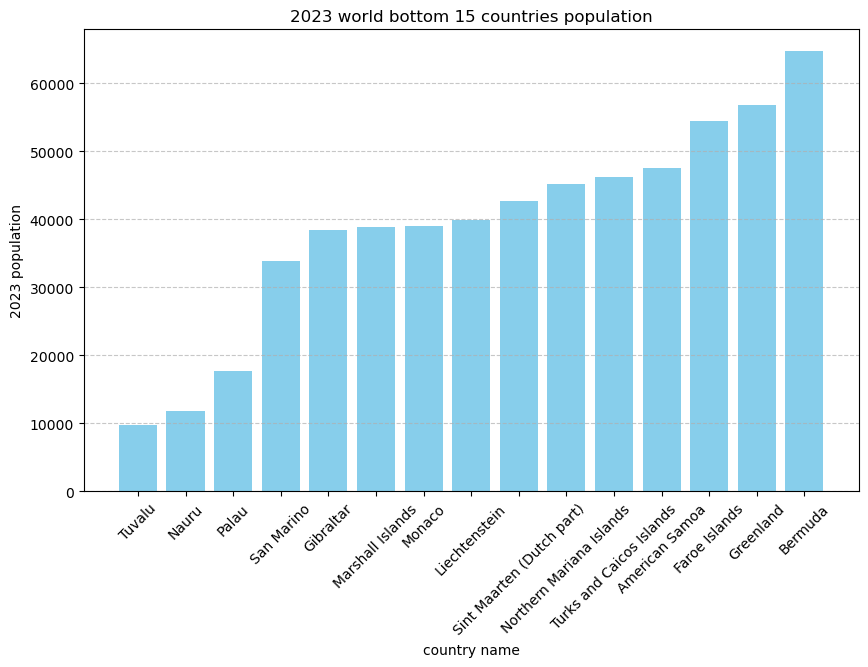

In [213]:
plt.figure(figsize=(10,6))
plt.bar(bottom15['country_name'],bottom15['2023'],color="skyblue")
plt.title("2023 world bottom 15 countries population")
plt.xlabel("country name")
plt.ylabel("2023 population")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [214]:
#from above chart it is observed that Tuvalu has only 10000 population it is country which has only 10000 peoples
#also we observed that bottom 15 countries has population is in range 10000 to 60000

# bar chart for top 15 contries in 1990

In [205]:
# Get the top 15 countries by population in 2023
top15_1990 = valid_countries[['country_name', '1990']].dropna().sort_values('1990', ascending=False).head(15)

print(top15_1990)

           country_name          1990
40                China  1.135185e+09
109               India  8.649722e+08
251       United States  2.496230e+08
106           Indonesia  1.835011e+08
29               Brazil  1.491432e+08
202  Russian Federation  1.479694e+08
119               Japan  1.234780e+08
184            Pakistan  1.161556e+08
20           Bangladesh  1.116337e+08
174             Nigeria  9.712092e+07
154              Mexico  8.282017e+07
55              Germany  7.943303e+07
257            Viet Nam  6.550455e+07
187         Philippines  6.285467e+07
77               France  5.826101e+07


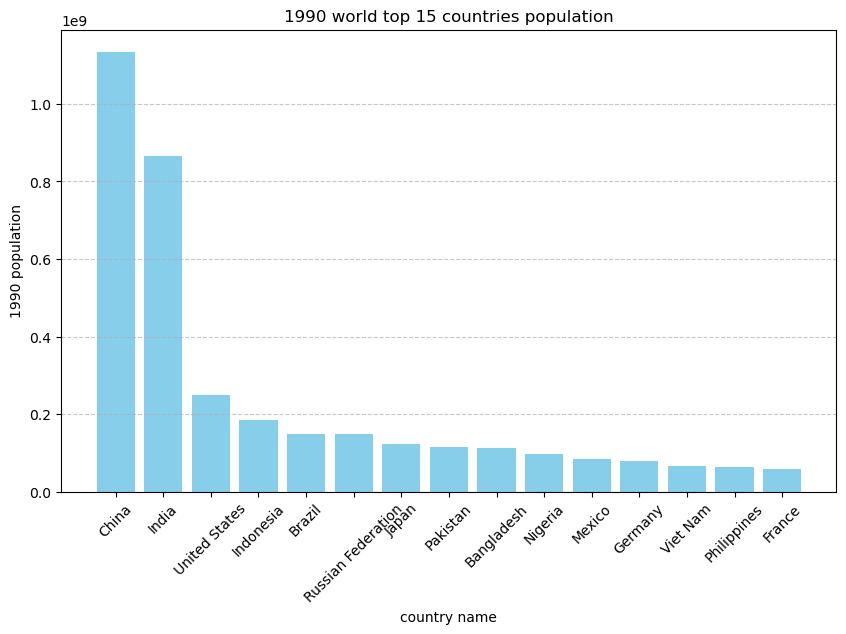

In [206]:
plt.figure(figsize=(10,6))
plt.bar(top15_1990['country_name'],top15_1990['1990'],color="skyblue")
plt.title("1990 world top 15 countries population")
plt.xlabel("country name")
plt.ylabel("1990 population")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [207]:
#in 1990 china has highest population
#in 1990 we can see that india has in between 0.8 to 0.9 billion population 

# lowest 15 contries in 1990

In [217]:
# Get the bottom 15 countries by population in 1990
bottom15_1990 = valid_countries[['country_name', '1990']].dropna().sort_values('1990', ascending=True).head(15)

print(bottom15_1990)

                  country_name     1990
245                     Tuvalu   8798.0
179                      Nauru   9622.0
228   Turks and Caicos Islands  11688.0
188                      Palau  15259.0
212                 San Marino  23475.0
52              Cayman Islands  25999.0
84                   Gibraltar  27200.0
225  Sint Maarten (Dutch part)  28061.0
137              Liechtenstein  28742.0
149                     Monaco  30358.0
164   Northern Mariana Islands  43342.0
155           Marshall Islands  44629.0
11              American Samoa  46640.0
78               Faroe Islands  47740.0
6                      Andorra  52597.0


# bar char for lowest population countries in 1990

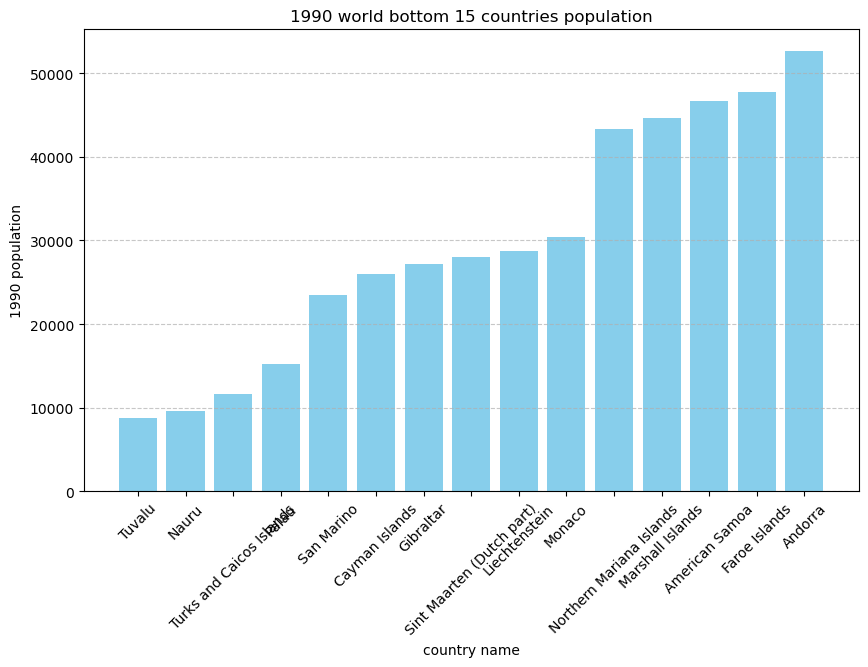

In [218]:
plt.figure(figsize=(10,6))
plt.bar(bottom15_1990['country_name'],bottom15_1990['1990'],color="skyblue")
plt.title("1990 world bottom 15 countries population")
plt.xlabel("country name")
plt.ylabel("1990 population")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [219]:
#from above bar chart it is observed that in 1990 Tuvalu has very low population i.e only less than 10000
#and lowest 15 country which has population is in range less than 10000 to more than 50000

# Histogram

In [208]:
#Histogram visualizes population distribution—how many countries fall within different population ranges.

# histogram for 2023 year

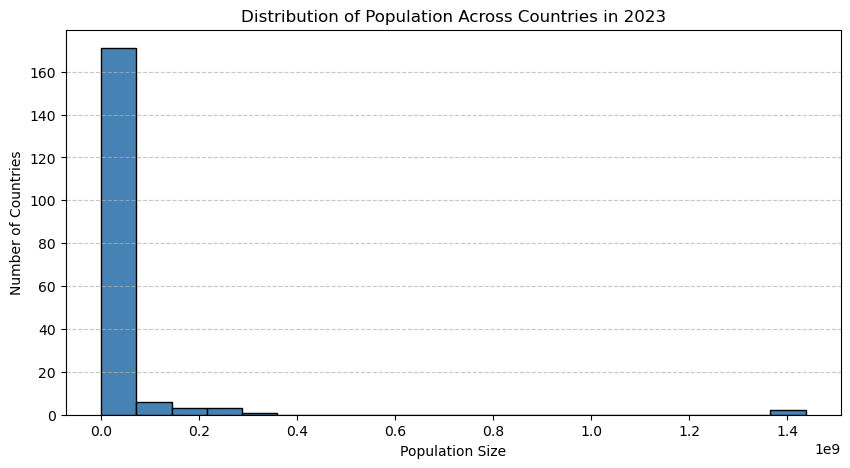

In [209]:
plt.figure(figsize=(10, 5))
plt.hist(valid_countries['2023'].dropna(), bins=20, color='steelblue', edgecolor='black')
plt.xlabel("Population Size")
plt.ylabel("Number of Countries")
plt.title("Distribution of Population Across Countries in 2023")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [210]:
#from above histogram of 2023 it is observe that in 2023 most of the countries has 0.1 billion i.e 100 million population i.e upto 170 country
#5 to 4 country has population 0.2 billion population
#1 or 2 country has population 0.2 billion 
#and very highest population i.e 1.4 billion has 1 or 2 country

# Observations

Observations from the Bar Chart:

A bar chart compares individual values—in this case, population sizes of the top 15 countries in 2023. Key observations include:
- Largest Populations Stand Out – Countries like China, India, and the USA will likely have the tallest bars, showing they have significantly larger populations.
- Population Differences Are Clear – A steep drop in bar heights might indicate that only a few countries have very high populations, while most have much smaller ones.
- Regional Patterns – Countries within the same continent or economic group may show similarities in population size (e.g., Asian countries leading, African countries showing rapid 

Observations from the Histogram:

A histogram groups population data into bins, helping us see overall trends rather than just individual values.
- Most Countries Have Small Populations – If the histogram is right-skewed, it means many countries have small populations, while only a few have very high ones.
- Outliers Are Easily Seen – The far-right bins will contain a few extreme cases, such as China and India, with billions of people.
- Population Clusters – The height of bars in different bins shows where most countries fall in terms of population size. If we see a peak around a specific range (e.g., 10–50 million), it suggests many countries have similar population sizes.
- Spread of Data – If the histogram has a wide spread, populations vary significantly among countries. If it's narrow, most countries have similar-sized populations.




# Benefits

Decision-Making – Governments, researchers, and businesses can use this data for planning resources, economic strategies, and social policies.

